In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.utils import resample
import constant as const


In [2]:
import warnings
warnings.filterwarnings("ignore")

url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)
print("done") 

Using: cuda
done


In [3]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

{'name': 'bestest_air'}


In [4]:
step = const.step
data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0

pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))

Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr
Ns_t, Ne_t = const.Ns_t, const.Ne_t

cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)

X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

class NN(nn.Module):
    def __init__(self, input_dim, hidden_dim=const.hidden_dim, output_dim=1, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                 nn.ReLU(),
                                 nn.Dropout(p=dropout_p),
                                 nn.Linear(hidden_dim, output_dim)
                                 )

    def forward(self, x):
        return self.net(x)

nx = 1
nu = 2
no = 1
num_committee = 10

In [5]:
def train_models(models, x_train, y_train, epochs, ini, save_ini_path, device):
    criterion = nn.MSELoss()
    x_train = x_train.to(device)
    y_train = y_train.to(device)
    save_path = []

    for i, model in enumerate(models):
        if not ini:
            model.load_state_dict(torch.load(save_ini_path[i], map_location=device))
        model.to(device)
        model.train()

        X_boot, y_boot = resample(x_train, y_train, replace=True, n_samples=len(x_train), random_state=i)

        optimizer = torch.optim.Adam(model.parameters(), lr=const.lr, weight_decay=1e-3)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = criterion(model(X_boot).squeeze(-1), y_boot)
            loss.backward()
            optimizer.step()

        path = f'checkpoints/model_QBC_NN_{i}.pth'
        torch.save(model.state_dict(), path)
        save_path.append(path)

    return models, save_path

In [6]:
def pred_qbc(models, x_test):
    predictions = []
    for model in models:
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            pred = model(x_test)
            predictions.append(pred)
    predictions = torch.stack(predictions)
    mean_prediction = torch.mean(predictions, dim=0)
    std = torch.std(predictions, dim=0)
    return mean_prediction, std

In [7]:
def evaluate_NN(models, X_t, y_t):
    mean_prediction, std = pred_qbc(models, X_t)
    
    with torch.no_grad():
        rmse = torch.sqrt(torch.mean((mean_prediction.squeeze(-1) - y_t)**2))
    return rmse

In [8]:
def acqui_func(models, U_grid, X_0, X_out, plot=False):
    num_points = U_grid.shape[0]
    scores = torch.zeros(num_points)
    

        

    N = U_grid.shape[0]
    X_cands = torch.cat([X_0.expand(N, -1), U_grid, X_out.expand(N, -1)], dim=1)

    predictions = []
    for model in models:
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            pred = model(X_cands).squeeze(-1).cpu().numpy() 
        predictions.append(pred)

    predictions = np.stack(predictions)
    scores = np.std(predictions, axis=0)
        
    ind     = int(np.argmax(scores))
    U_optim = U_grid[ind]

    if plot:
        u1_vals = torch.unique(U_grid[:, 0]).cpu().numpy()
        u2_vals = torch.unique(U_grid[:, 1]).cpu().numpy()

        n1 = len(u1_vals)
        n2 = len(u2_vals)
        s_map = np.zeros((n2, n1))

        for k in range(len(scores)):
            i = np.where(u1_vals == U_grid[k, 0].cpu().numpy())[0][0]
            j = np.where(u2_vals == U_grid[k, 1].cpu().numpy())[0][0]
            s_map[j, i] = scores[k].item()

        plt.figure(figsize=(6,5))
        cp = plt.imshow(
            s_map,
            extent=[u1_vals.min(), u1_vals.max(),
                    u2_vals.min(), u2_vals.max()],
            origin="lower",
            aspect="auto"
        )

        print("Max score:", scores[ind].item())

        plt.colorbar(cp, label="Expected Model Change (Score)")
        plt.scatter(
            U_optim[0].cpu(),
            U_optim[1].cpu(),
            c="red",
            marker="x",
            s=100
        )
        plt.xlabel("u1 (Supply)")
        plt.ylabel("u2 (Airflow)")
        plt.title("BEMCM Acquisition Landscape")
        plt.show()


    return U_optim

class MPC:
    def __init__(self, models, device='cpu'):
        self.device = device
        self.models = models

    def mpc_grid_search(self, u0_1, u0_2, X_0, X_out, n_grid, plot=True):
        X_0_norm = torch.tensor(X_0, dtype=torch.float32, device=self.device).view(1, -1) / 30.0
        x_out_norm = torch.tensor(X_out, dtype=torch.float32, device=self.device).view(1, -1) / 10.0

        u1_vals = torch.linspace(max(u0_1-const.ramp, 0.3), min(u0_1+const.ramp, 1.0), n_grid)
        u2_vals = torch.linspace(max(u0_2-const.ramp, 0.0), min(u0_2+const.ramp, 1.0), n_grid)

        u1_vals = u1_vals[~torch.isclose(u1_vals, torch.tensor(u0_1))]
        u2_vals = u2_vals[~torch.isclose(u2_vals, torch.tensor(u0_2))]
        
        U_grid = torch.cartesian_prod(u1_vals, u2_vals).to(self.device)
                
        best_u = acqui_func(self.models, U_grid, X_0_norm, x_out_norm, plot=plot)

        return best_u, {
            'fcu_oveTSup_u': float(best_u[0] * 40 + 273.15),
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u': float(best_u[1]),
            'fcu_oveFan_activate': 1
        }

In [9]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':const.step*60})
start_time_days = y['time']/3600/24

In [10]:
models = []
for i in range(num_committee):
    model = NN(input_dim=nx+nu+no, hidden_dim=const.hidden_dim, output_dim=nx, dropout_p=0.0)
    models.append(model)

save_ini_path = ['checkpoints/model_ini_AL_NN.pth'] * num_committee
models, save_com_path = train_models(models, X_tr, y_tr, epochs=const.epoch_ini, ini=True,
                                     save_ini_path=save_ini_path, device=device)

counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {'fcu_oveTSup_u': u0_1 * 40 + 273.15,
     'fcu_oveTSup_activate': 1,
     'fcu_oveFan_u': u0_2,
     'fcu_oveFan_activate': 1}

y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']

ls_rmse = [evaluate_NN(models, X_t, y_t)]
X_tr_new = X_tr
y_tr_new = y_tr

n_grid = 10

In [11]:
while y:
    x0 = y['zon_reaTRooAir_y'] - 273.15
    x_out = y['zon_weaSta_reaWeaTDryBul_y'] - 273.15
    print('-------------------------------------------------------------------')
    print('Step counter =', counter)

    counter += 1
    mpc_controller = MPC(models, device=device)
    best_u, u = mpc_controller.mpc_grid_search(u0_1=u0_1, u0_2=u0_2, X_0=x0, X_out=x_out,
                                                n_grid=n_grid, plot=False)
    print('best_u (normalized):', best_u.cpu().numpy())

    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']

    cur = to_tensor(x0).view(-1, 1) / 30.0
    T_sup_add = to_tensor((u['fcu_oveTSup_u'] - 273.15) / 40.0).view(-1, 1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1, 1)
    pos_add = to_tensor(y['zon_reaTRooAir_y'] - 273.15).view(-1, 1) / 30.0
    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y'] - 273.15) / 10.0).view(-1, 1)

    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)
    y_tr_n = pos_add.squeeze(-1)

    X_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0)
    y_tr_new = torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if const.count_data == const.number_of_data:
        models, save_com_path = train_models(models, X_tr_new, y_tr_new, const.epoch_onl,
                                            ini=False, save_ini_path=save_com_path, device=device)
        const.count_data = 0
    const.count_data += 1

    rmse = evaluate_NN(models, X_t, y_t)
    ls_rmse.append(rmse)

    u0_1 = (u['fcu_oveTSup_u'] - 273.15) / 40.0
    u0_2 = u['fcu_oveFan_u']

    if counter > const.num_count:
        break

-------------------------------------------------------------------
Step counter = 0
best_u (normalized): [0.7 0.7]
-------------------------------------------------------------------
Step counter = 1
best_u (normalized): [0.89999986 0.9       ]
-------------------------------------------------------------------
Step counter = 2
best_u (normalized): [1. 1.]
-------------------------------------------------------------------
Step counter = 3
best_u (normalized): [0.9777778 0.9777778]
-------------------------------------------------------------------
Step counter = 4
best_u (normalized): [1. 1.]
-------------------------------------------------------------------
Step counter = 5
best_u (normalized): [0.9777778 0.9777778]
-------------------------------------------------------------------
Step counter = 6
best_u (normalized): [1. 1.]
-------------------------------------------------------------------
Step counter = 7
best_u (normalized): [0.9777778 0.9777778]
----------------------------

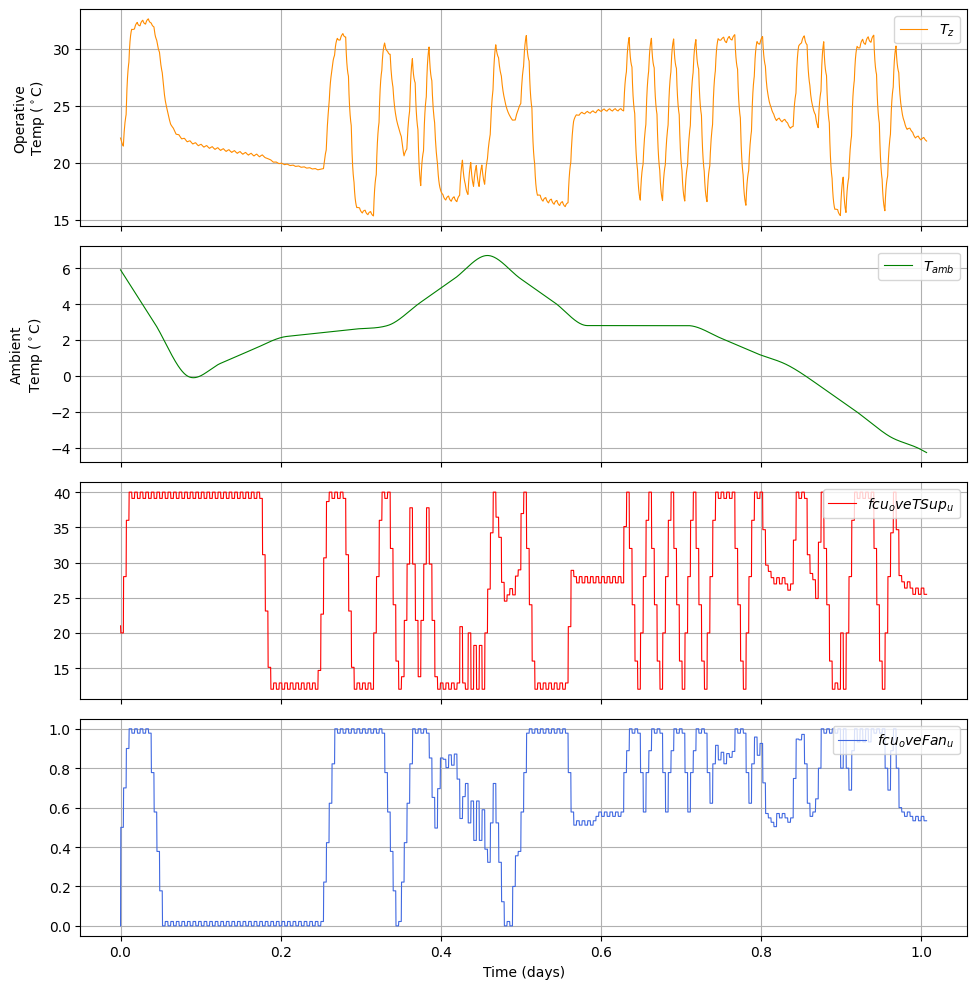

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.15000,0.000000,279.050000,0.000000
3801630,295.222125,293.15000,0.500000,279.025812,0.000347
3801660,295.117210,293.15000,0.500000,279.001625,0.000694
3801690,295.023884,293.15000,0.500000,278.977439,0.001042
3801720,294.940950,293.15000,0.500000,278.953254,0.001389
...,...,...,...,...,...
3888480,295.137660,298.63147,0.533333,268.916667,1.005556
3888510,295.111938,298.63147,0.533333,268.908333,1.005903
3888540,295.088686,298.63147,0.533333,268.900000,1.006250


In [12]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    

    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

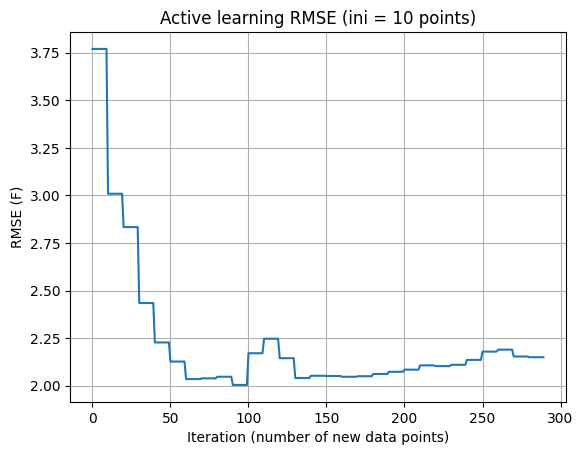

In [13]:
ls_rmse = [r.item()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title(f'Active learning RMSE (ini = {Ne_tr} points)')
plt.show()
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_QBC_NN"])

save_path = f"RMSE_QBC_NN_ini{Ne_tr}_lr{const.lr}_ramp{const.ramp}.csv"                   
full_path = os.path.join(save_dir, save_path)               
df.to_csv(full_path, index=False)     

: 